# Simple and Weighted Forecast Combination

**Forecast combination** is one of the most robust strategies in time series forecasting.
The seminal paper by **Bates & Granger (1969)** showed that combining two forecasts
can reduce prediction error, even when one model is clearly inferior.

> *"The combination of forecasts is a simple, practical, and effective approach
> to improving forecast accuracy."* -- Bates & Granger (1969)

The **forecast combination puzzle** (Stock & Watson, 2004) refers to the empirical finding
that simple averages of forecasts often outperform more sophisticated weighting schemes.
This notebook explores simple and weighted combination methods to understand why.

**Topics covered:**
- Simple average combination
- Inverse MSE weighting
- Trimmed mean combination
- Performance comparison across methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecastbox.combination import SimpleCombiner, WeightedCombiner
from forecastbox.core.forecast import Forecast
from forecastbox.metrics import mae, rmse

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
np.random.seed(42)

## 1. Why Combine Forecasts?

Forecast combination works for two main reasons:

1. **Diversification**: Different models capture different patterns in the data.
   By combining them, we hedge against any single model being wrong.

2. **Variance reduction**: Even if all models are unbiased, their errors are
   imperfectly correlated. The combined forecast has lower variance than
   any individual forecast (analogous to portfolio diversification in finance).

Mathematically, for K models with equal weights:

$$\text{Var}(\bar{f}) = \frac{1}{K^2}\sum_{i=1}^{K}\sum_{j=1}^{K}\text{Cov}(e_i, e_j) \leq \frac{1}{K}\bar{\sigma}^2$$

The combined variance is always less than or equal to the average individual variance,
with equality only when all errors are perfectly correlated.

In [2]:
# Load inflation forecasts dataset
df = pd.read_csv("../../data/inflation_forecasts.csv", parse_dates=["date"])
print(f"Dataset shape: {df.shape}")
print(f"Period: {df['date'].min()} to {df['date'].max()}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (120, 7)
Period: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
Columns: ['date', 'actual', 'fc_arima', 'fc_ets', 'fc_var', 'fc_naive', 'fc_drift']


,date,actual,fc_arima,fc_ets,fc_var,fc_naive,fc_drift
0,2015-01-01,0.4000,0.4009,0.3371,0.3823,0.4000,0.5838
1,2015-02-01,0.4155,0.3536,0.3178,0.3972,0.4000,0.3864
2,2015-03-01,0.3094,0.3437,0.2899,0.3554,0.4155,0.3900
3,2015-04-01,0.4261,0.4637,0.2404,0.5461,0.3094,0.3869
4,2015-05-01,0.5143,0.6431,0.3576,0.3873,0.4261,0.5200


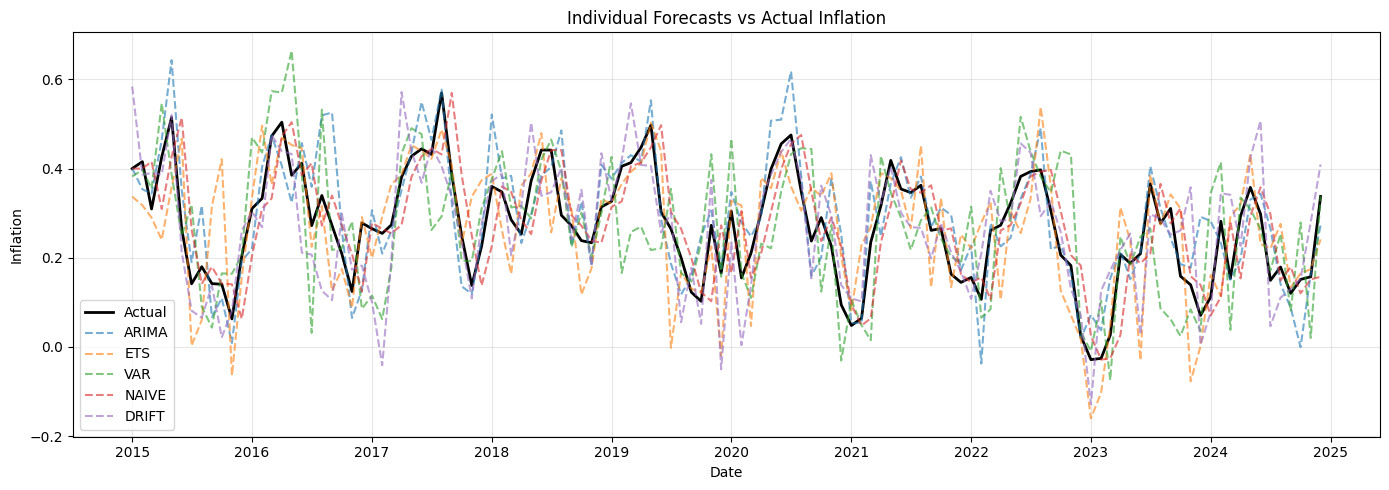

In [3]:
# Visualize individual forecasts vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["actual"], "k-", linewidth=2, label="Actual")
for col in ["fc_arima", "fc_ets", "fc_var", "fc_naive", "fc_drift"]:
    ax.plot(df["date"], df[col], "--", alpha=0.6, label=col.replace("fc_", "").upper())
ax.set_title("Individual Forecasts vs Actual Inflation")
ax.set_xlabel("Date")
ax.set_ylabel("Inflation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Simple Average

The simplest combination method assigns **equal weights** to all models:

$$\hat{y}_{c,t} = \frac{1}{K}\sum_{k=1}^{K}\hat{y}_{k,t}$$

Despite its simplicity, the simple average is remarkably hard to beat:
- It requires no estimation, so there is **no estimation error** in the weights.
- When the true optimal weights are uncertain, the simple average is a robust default.
- Stock & Watson (2004) showed it often outperforms estimated-weight methods in macro forecasting.

In [4]:
# Split into train (first 80 obs) and test (last 40 obs)
n_train = 80
train_df = df.iloc[:n_train]
test_df = df.iloc[n_train:]

actual_train = train_df["actual"].values
actual_test = test_df["actual"].values

model_cols = ["fc_arima", "fc_ets", "fc_var", "fc_naive", "fc_drift"]
model_names = [c.replace("fc_", "").upper() for c in model_cols]

# Prepare training arrays for fit()
forecasts_train = [train_df[col].values for col in model_cols]

# Prepare Forecast objects for combine()
forecasts_test = [
    Forecast(point=test_df[col].values, model_name=name)
    for col, name in zip(model_cols, model_names)
]

# Simple Average combination
simple_combiner = SimpleCombiner(method="mean")
simple_combiner.fit(forecasts_train, actual_train)  # no-op for SimpleCombiner
fc_simple_avg = simple_combiner.combine(forecasts_test)

print("Simple Average weights:", simple_combiner.weights_)
print(f"MAE (Simple Avg): {mae(actual_test, fc_simple_avg.point):.4f}")
print(f"RMSE (Simple Avg): {rmse(actual_test, fc_simple_avg.point):.4f}")

# Compare with best individual model
print("\nIndividual model performance (test set):")
for name, col in zip(model_names, model_cols):
    print(f"  {name:8s}  MAE={mae(actual_test, test_df[col].values):.4f}  "
          f"RMSE={rmse(actual_test, test_df[col].values):.4f}")

Simple Average weights: [0.2 0.2 0.2 0.2 0.2]
MAE (Simple Avg): 0.0323
RMSE (Simple Avg): 0.0400

Individual model performance (test set):
  ARIMA     MAE=0.0605  RMSE=0.0793
  ETS       MAE=0.0837  RMSE=0.1020
  VAR       MAE=0.0883  RMSE=0.1135
  NAIVE     MAE=0.0714  RMSE=0.0912
  DRIFT     MAE=0.0752  RMSE=0.0930


## 3. Inverse MSE Weighting

Instead of equal weights, we can assign higher weights to models with **lower historical error**.
Inverse MSE weighting sets:

$$w_k = \frac{1/\text{MSE}_k}{\sum_{j=1}^{K} 1/\text{MSE}_j}$$

This is a natural performance-based weighting scheme:
- Models with lower MSE receive higher weights.
- The weights are always positive and sum to 1.
- It is equivalent to the **Bates-Granger (1969)** optimal weights when errors are uncorrelated.

Inverse MSE Weights:
  ARIMA   : 0.2719
  ETS     : 0.1793
  VAR     : 0.1305
  NAIVE   : 0.2156
  DRIFT   : 0.2027

Training MSE per model:
  ARIMA   : 0.006944
  ETS     : 0.010531
  VAR     : 0.014464
  NAIVE   : 0.008755
  DRIFT   : 0.009316

MAE (Inverse MSE): 0.0341
RMSE (Inverse MSE): 0.0417


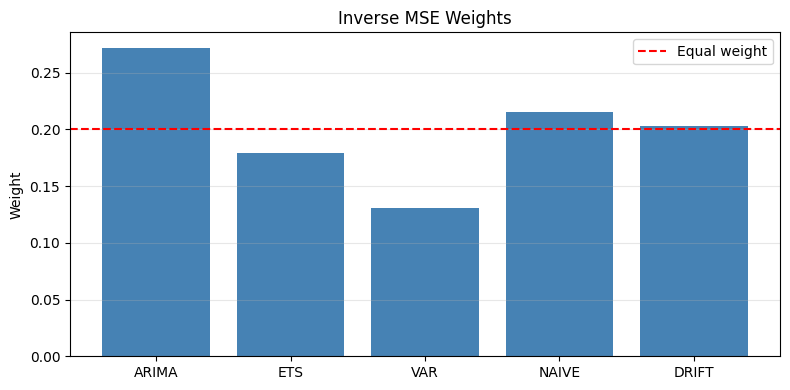

In [5]:
# Inverse MSE weighting
weighted_combiner = WeightedCombiner(method="inverse_mse")
weighted_combiner.fit(forecasts_train, actual_train)
fc_weighted = weighted_combiner.combine(forecasts_test)

# Display weights
print("Inverse MSE Weights:")
for name, w in zip(model_names, weighted_combiner.weights_):
    print(f"  {name:8s}: {w:.4f}")

print(f"\nTraining MSE per model:")
for name, m in zip(model_names, weighted_combiner.mse_):
    print(f"  {name:8s}: {m:.6f}")

print(f"\nMAE (Inverse MSE): {mae(actual_test, fc_weighted.point):.4f}")
print(f"RMSE (Inverse MSE): {rmse(actual_test, fc_weighted.point):.4f}")

# Visualize weights
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(model_names, weighted_combiner.weights_, color="steelblue")
ax.axhline(y=1/len(model_names), color="red", linestyle="--", label="Equal weight")
ax.set_ylabel("Weight")
ax.set_title("Inverse MSE Weights")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. Trimmed Mean

The **trimmed mean** removes extreme forecasts before averaging.
This is useful when some models produce outlier predictions.

With a trim fraction of $\alpha$, we discard the lowest $\alpha$ and highest $\alpha$
fraction of forecasts at each time point, then average the remaining ones.

This is equivalent to removing the 2 worst models (for 5 models with ~20% trim)
and averaging the remaining 3.

Trimmed Mean (trim_fraction=0.2):
  MAE:  0.0325
  RMSE: 0.0408

Median Combination:
  MAE:  0.0364
  RMSE: 0.0459


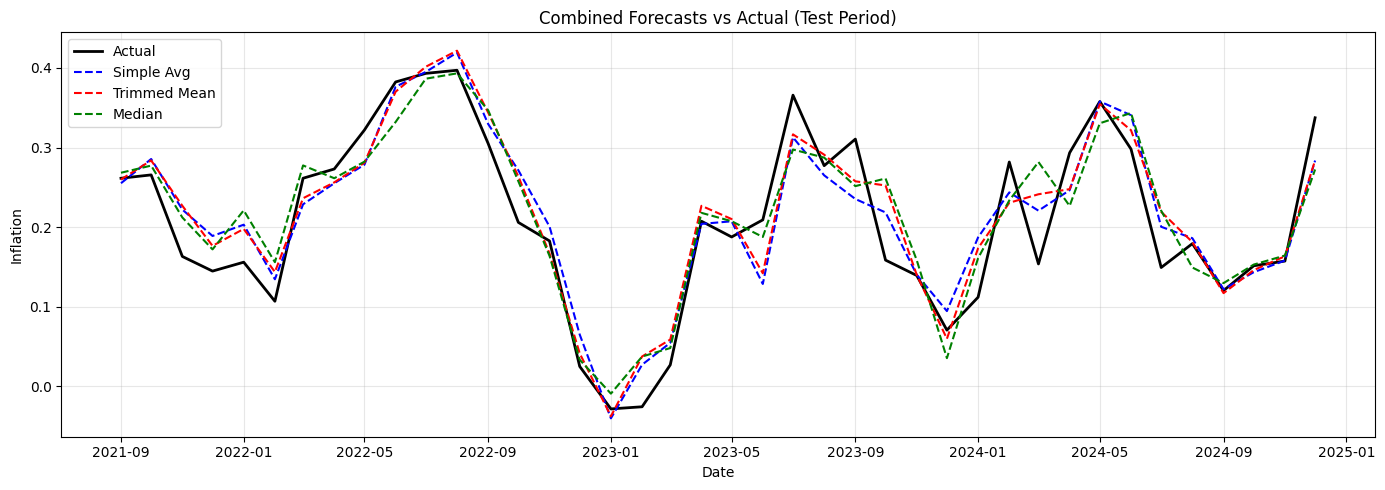

In [6]:
# Trimmed mean: remove the 2 most extreme forecasts at each time point
# With 5 models and trim_fraction=0.2, we trim 1 from each tail
trimmed_combiner = SimpleCombiner(method="trimmed", trim_fraction=0.2)
trimmed_combiner.fit(forecasts_train, actual_train)
fc_trimmed = trimmed_combiner.combine(forecasts_test)

print(f"Trimmed Mean (trim_fraction=0.2):")
print(f"  MAE:  {mae(actual_test, fc_trimmed.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_trimmed.point):.4f}")

# Also try median combination
median_combiner = SimpleCombiner(method="median")
median_combiner.fit(forecasts_train, actual_train)
fc_median = median_combiner.combine(forecasts_test)

print(f"\nMedian Combination:")
print(f"  MAE:  {mae(actual_test, fc_median.point):.4f}")
print(f"  RMSE: {rmse(actual_test, fc_median.point):.4f}")

# Plot combined forecasts vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df["date"], actual_test, "k-", linewidth=2, label="Actual")
ax.plot(test_df["date"], fc_simple_avg.point, "b--", label="Simple Avg")
ax.plot(test_df["date"], fc_trimmed.point, "r--", label="Trimmed Mean")
ax.plot(test_df["date"], fc_median.point, "g--", label="Median")
ax.set_title("Combined Forecasts vs Actual (Test Period)")
ax.set_xlabel("Date")
ax.set_ylabel("Inflation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Performance Comparison

Let's create a comprehensive comparison table of all individual models
and combination methods using MAE and RMSE.

In [7]:
# Build comparison table
results = []

# Individual models
for name, col in zip(model_names, model_cols):
    pred = test_df[col].values
    results.append({
        "Method": name,
        "Type": "Individual",
        "MAE": mae(actual_test, pred),
        "RMSE": rmse(actual_test, pred),
    })

# Combination methods
combinations = {
    "Simple Average": fc_simple_avg,
    "Inverse MSE": fc_weighted,
    "Trimmed Mean": fc_trimmed,
    "Median": fc_median,
}

for name, fc in combinations.items():
    results.append({
        "Method": name,
        "Type": "Combination",
        "MAE": mae(actual_test, fc.point),
        "RMSE": rmse(actual_test, fc.point),
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("RMSE")
print("Performance Comparison (sorted by RMSE)")
print("=" * 55)
comparison_df.round(4)

Performance Comparison (sorted by RMSE)


,Method,Type,MAE,RMSE
5,Simple Average,Combination,0.0323,0.0400
7,Trimmed Mean,Combination,0.0325,0.0408
6,Inverse MSE,Combination,0.0341,0.0417
8,Median,Combination,0.0364,0.0459
0,ARIMA,Individual,0.0605,0.0793
3,NAIVE,Individual,0.0714,0.0912
4,DRIFT,Individual,0.0752,0.0930
1,ETS,Individual,0.0837,0.1020
2,VAR,Individual,0.0883,0.1135


## Exercise 1: Apply weighted combination to M4 sample series

Load `m4_sample.csv`, pick one series (e.g., `M4_001`), and apply both
simple average and inverse MSE weighting. Compare results.

In [8]:
# Solution: Exercise 1
# Apply weighted combination to each M4 sample series

m4 = pd.read_csv("../../data/m4_sample.csv")
model_cols_m4 = ["fc_model1", "fc_model2", "fc_model3"]
model_names_m4 = ["Model1", "Model2", "Model3"]

results_ex1 = []

for sid in m4["series_id"].unique():
    series = m4[m4["series_id"] == sid].reset_index(drop=True)
    n_tr = int(len(series) * 0.8)  # 96 obs train, 24 test
    train_s = series.iloc[:n_tr]
    test_s = series.iloc[n_tr:]

    actual_tr = train_s["actual"].values
    actual_te = test_s["actual"].values
    fc_tr = [train_s[c].values for c in model_cols_m4]
    fc_te = [
        Forecast(point=test_s[c].values, model_name=n)
        for c, n in zip(model_cols_m4, model_names_m4)
    ]

    # Simple average
    sa = SimpleCombiner(method="mean")
    sa.fit(fc_tr, actual_tr)
    fc_sa = sa.combine(fc_te)
    mae_sa = mae(actual_te, fc_sa.point)

    # Inverse MSE
    wc = WeightedCombiner(method="inverse_mse")
    wc.fit(fc_tr, actual_tr)
    fc_wc = wc.combine(fc_te)
    mae_wc = mae(actual_te, fc_wc.point)

    # Best individual model
    best_mae = min(
        mae(actual_te, test_s[c].values) for c in model_cols_m4
    )
    best_name = min(
        model_names_m4,
        key=lambda n: mae(actual_te, test_s[model_cols_m4[model_names_m4.index(n)]].values),
    )

    results_ex1.append({
        "Series": sid,
        "Simple Avg MAE": mae_sa,
        "Inverse MSE MAE": mae_wc,
        "Best Individual MAE": best_mae,
        "Best Model": best_name,
    })

results_df = pd.DataFrame(results_ex1)
print("Weighted Combination Results on M4 Sample")
print("=" * 70)
print(results_df.to_string(index=False, float_format="{:.4f}".format))

# Summary
print(f"\nAverage MAE:")
print(f"  Simple Average:    {results_df['Simple Avg MAE'].mean():.4f}")
print(f"  Inverse MSE:       {results_df['Inverse MSE MAE'].mean():.4f}")
print(f"  Best Individual:   {results_df['Best Individual MAE'].mean():.4f}")

# Observation: combination methods often outperform the best individual model
# because they hedge against model-specific errors.


Weighted Combination Results on M4 Sample
Series  Simple Avg MAE  Inverse MSE MAE  Best Individual MAE Best Model
M4_001          1.0781           1.0708               1.5950     Model1
M4_002          1.4915           1.3185               1.5004     Model1
M4_003          1.2762           1.0690               1.6879     Model1
M4_004          1.2560           1.1495               1.4983     Model1
M4_005          1.0836           0.9252               1.3083     Model1
M4_006          1.2471           1.2464               1.4546     Model1

Average MAE:
  Simple Average:    1.2387
  Inverse MSE:       1.1299
  Best Individual:   1.5074


## Exercise 2: Find optimal number of models to trim

Test different `trim_fraction` values from 0.0 to 0.4 and plot the
resulting RMSE. What is the optimal trim fraction for this dataset?

  trim_fraction=0.00  MAE=0.0323
  trim_fraction=0.05  MAE=0.0323
  trim_fraction=0.10  MAE=0.0323
  trim_fraction=0.15  MAE=0.0323
  trim_fraction=0.20  MAE=0.0325
  trim_fraction=0.25  MAE=0.0325
  trim_fraction=0.30  MAE=0.0325
  trim_fraction=0.35  MAE=0.0325
  trim_fraction=0.40  MAE=0.0364

Optimal trim_fraction: 0.00 (MAE=0.0323)


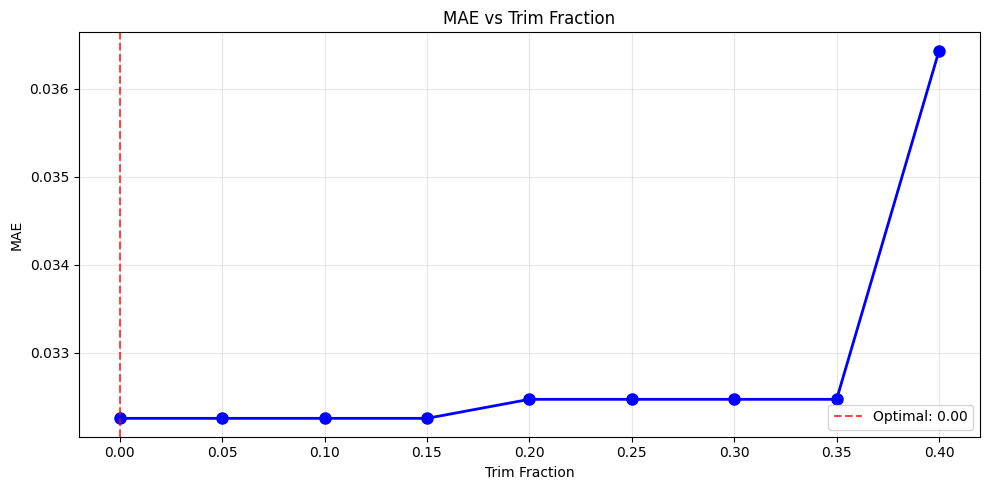

In [9]:
# Solution: Exercise 2
# Loop over trim_fraction values and find the optimal one

trim_fractions = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
mae_values = []

for tf in trim_fractions:
    tc = SimpleCombiner(method="trimmed", trim_fraction=tf)
    tc.fit(forecasts_train, actual_train)
    fc_tc = tc.combine(forecasts_test)
    mae_val = mae(actual_test, fc_tc.point)
    mae_values.append(mae_val)
    print(f"  trim_fraction={tf:.2f}  MAE={mae_val:.4f}")

# Find optimal
optimal_idx = np.argmin(mae_values)
optimal_tf = trim_fractions[optimal_idx]
print(f"\nOptimal trim_fraction: {optimal_tf:.2f} (MAE={mae_values[optimal_idx]:.4f})")

# Plot MAE vs trim_fraction
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trim_fractions, mae_values, "bo-", linewidth=2, markersize=8)
ax.axvline(x=optimal_tf, color="red", linestyle="--", alpha=0.7,
           label=f"Optimal: {optimal_tf:.2f}")
ax.set_xlabel("Trim Fraction")
ax.set_ylabel("MAE")
ax.set_title("MAE vs Trim Fraction")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Note: trim_fraction=0.0 is equivalent to simple mean.
# As trim_fraction increases, we remove more extreme forecasts,
# which can help if some models produce outlier predictions.
